# Table of Content

- [1. Introduction](#1-introduction)
  - [1.1 Problem Statement](#11-problem-statement)
  - [1.2 Dataset](#12-dataset)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling](#3-modelling)
- [4. Evaluation](#4-evaluation)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)

# 1. Introduction



## 1.1 Problem Statement

## 1.2 Dataset

In [24]:
# Import Libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
# preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_squared_log_error, make_scorer


In [2]:

# Create a df describing each variable
variables = [
    "instant", "dteday", "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit", "temp", "atemp", "hum",
    "windspeed", "casual", "registered", "cnt"
]

descriptions = [
    "Record index",
    "Date of the observation",
    "Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)",
    "Year (0: 2011, 1: 2012)",
    "Month (1 to 12)",
    "Hour (0 to 23) – not available in day.csv",
    "Indicator if the day is a holiday (1: holiday, 0: not)",
    "Day of the week (0: Sunday to 6: Saturday)",
    "Indicator if day is working day (1) or weekend/holiday (0)",
    "Weather situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)",
    "Normalized temperature in Celsius (divided by 41)",
    "Normalized feeling temperature in Celsius (divided by 50)",
    "Normalized humidity (divided by 100)",
    "Normalized wind speed (divided by 67)",
    "Count of casual users (leisure)",
    "Count of registered users (subscribers)",
    "Total count of bike rentals (casual + registered)"
]

df_variables = pd.DataFrame({
    "Variable": variables,
    "Description": descriptions
})


df_variables.head(18)



,Variable,Description
0,instant,Record index
1,dteday,Date of the observation
2,season,"Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)"
3,yr,"Year (0: 2011, 1: 2012)"
4,mnth,Month (1 to 12)
5,hr,Hour (0 to 23) – not available in day.csv
6,holiday,"Indicator if the day is a holiday (1: holiday,..."
7,weekday,Day of the week (0: Sunday to 6: Saturday)
8,workingday,Indicator if day is working day (1) or weekend...
9,weathersit,"Weather situation (1: Clear/Few clouds, 2: Mis..."


In [3]:
day_bike = pd.read_csv('day.csv')
day_bike.head(10)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [4]:
day_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
#Get basic idea of data using describe()
day_bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
def enhanced_data_overview(df, head_rows=5):
    """
    Displays an extended overview of the DataFrame:
    - Shape (rows, columns)
    - Memory usage
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """
    # 1. Shape
    display(Markdown("## Shape"))
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
    
    # 2. Memory Usage
    display(Markdown("## Memory Usage"))
    mem_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"Total Memory Usage: {mem_usage:.2f} MB\n")
    
    # 3. Missing Values
    display(Markdown("## Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("## Duplicate Rows"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("## Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("## Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique(),
        'Data Type': df.dtypes
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("## Head (First Rows)"))
    display(df.head(head_rows))

    # 8. Bottom (last rows)
    display(Markdown("## Bottom (Last Rows)"))
    display(df.tail(head_rows))

    #9. Descriptive Statistics
    display(Markdown("## Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

## Shape

Rows: 731, Columns: 16



## Memory Usage

Total Memory Usage: 0.13 MB



## Missing Values

...

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Bottom (Last Rows)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


## Descriptive Statistics

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


# 2. Methodology

# 2.1 Data Preprocessing

In [7]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extracts categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

In [8]:
# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Display the categorical and numerical variables
print("Categorical Variables:")
print(categorical_variables)

print("\nNumerical Variables:")
print(numerical_variables)




Categorical Variables:
['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical Variables:
['instant', 'temperature', 'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered', 'total_count']


# 2.2 Data Analysis

## Descriptive Statistics for Numerical Features

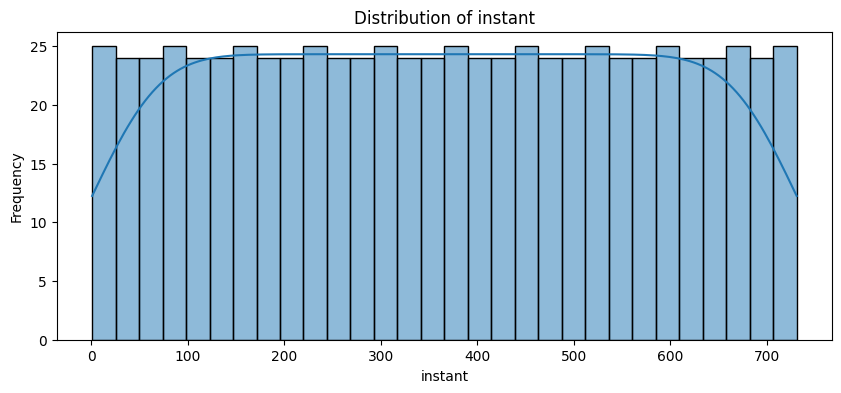

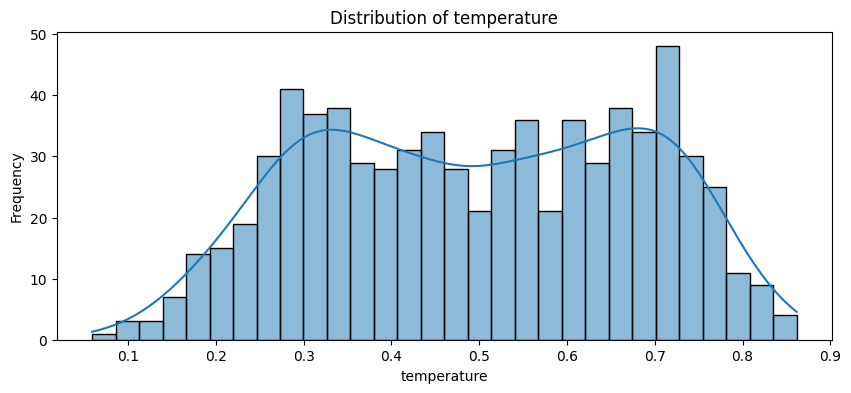

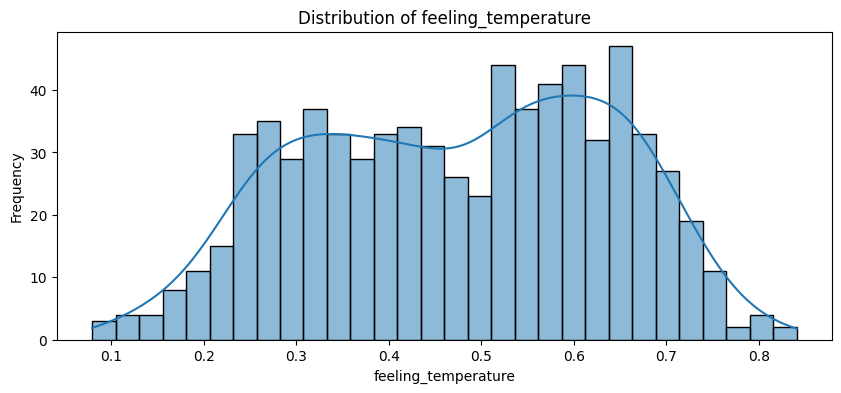

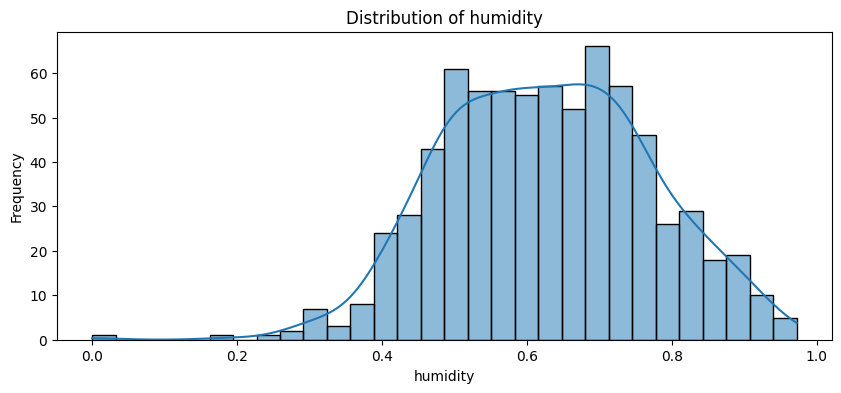

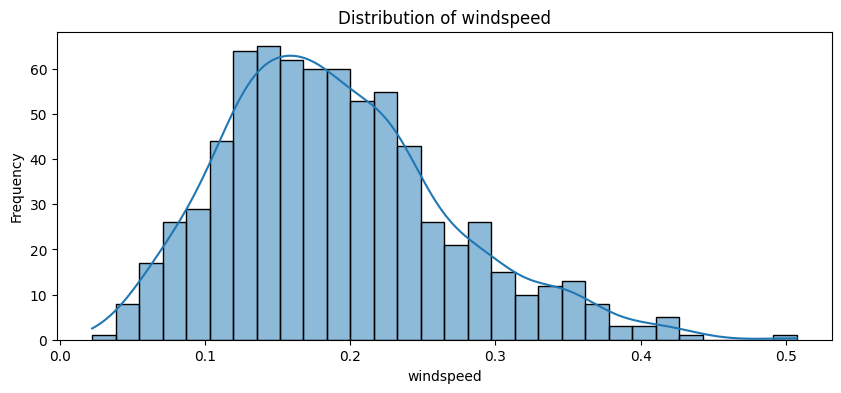

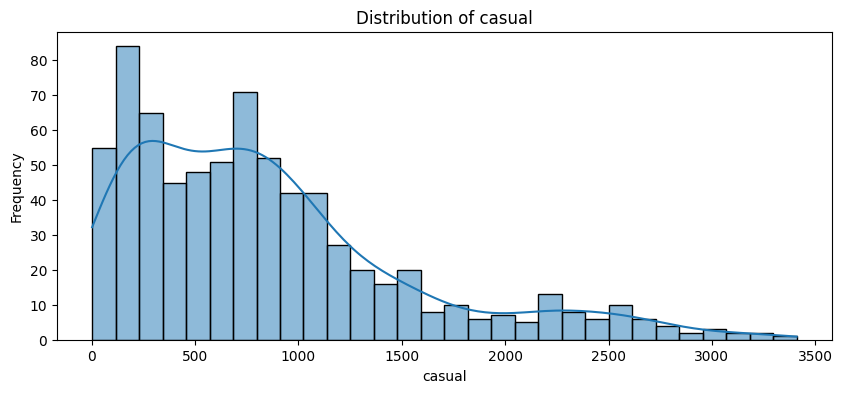

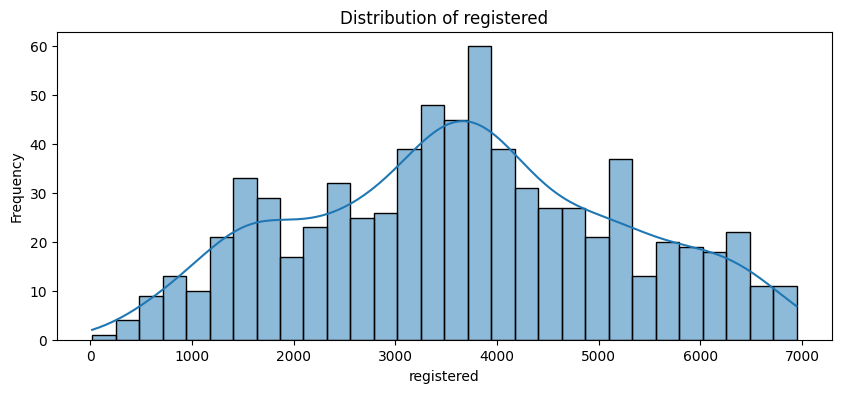

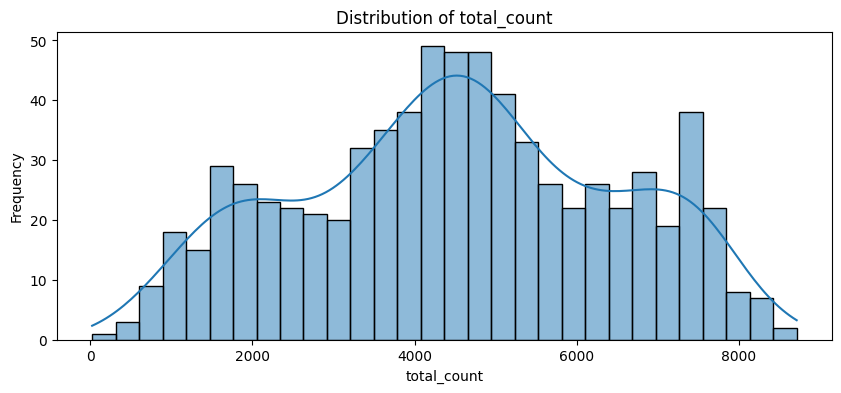

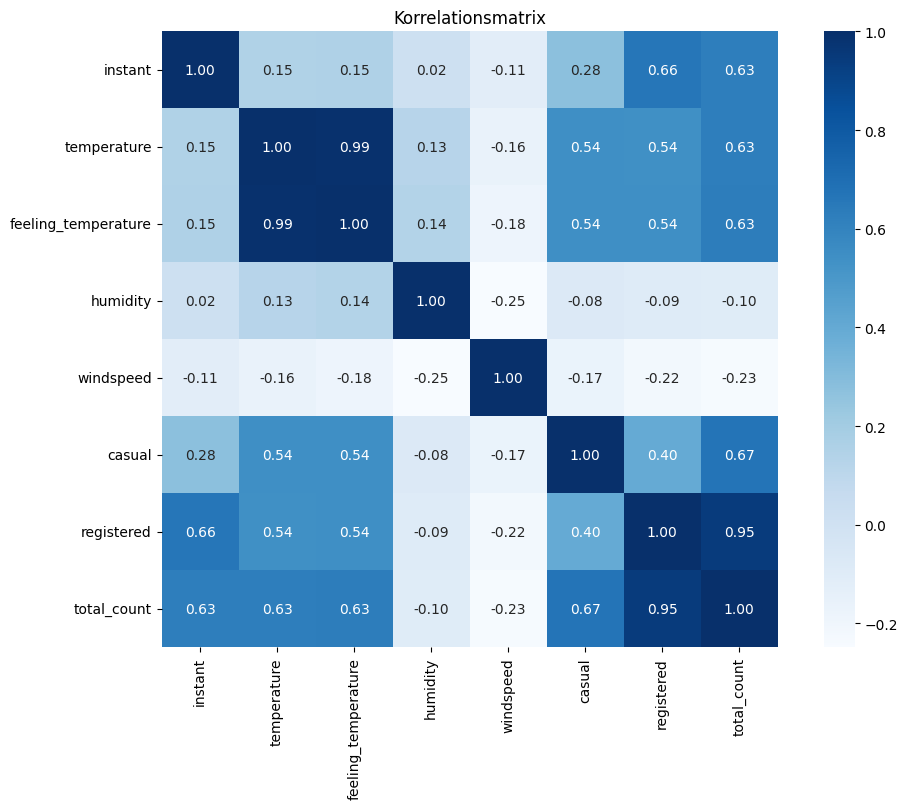

In [10]:
# TODO:
# 1. Alyse numerical variables
# 2. Visualize categorical variables
def analyze_numerical_features(df, numerical_features):
    """
    Analyzes numerical features in the DataFrame:
    - Displays descriptive statistics
    - Visualizes distributions and correlations
    """
    # Descriptive statistics
    display(Markdown("## Descriptive Statistics for Numerical Features"))
   

    # Visualize distributions of numerical features
    for feature in numerical_features:
        plt.figure(figsize=(10, 4))
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.show()

# Analyze numerical features
analyze_numerical_features(day_bike, numerical_variables)

# Korrelationsmatrix (Heatmap) mit blauen Farben
def plot_correlation_matrix(df, numerical_features):    
    """
    Plots a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    plt.title('Korrelationsmatrix')
    plt.show()

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

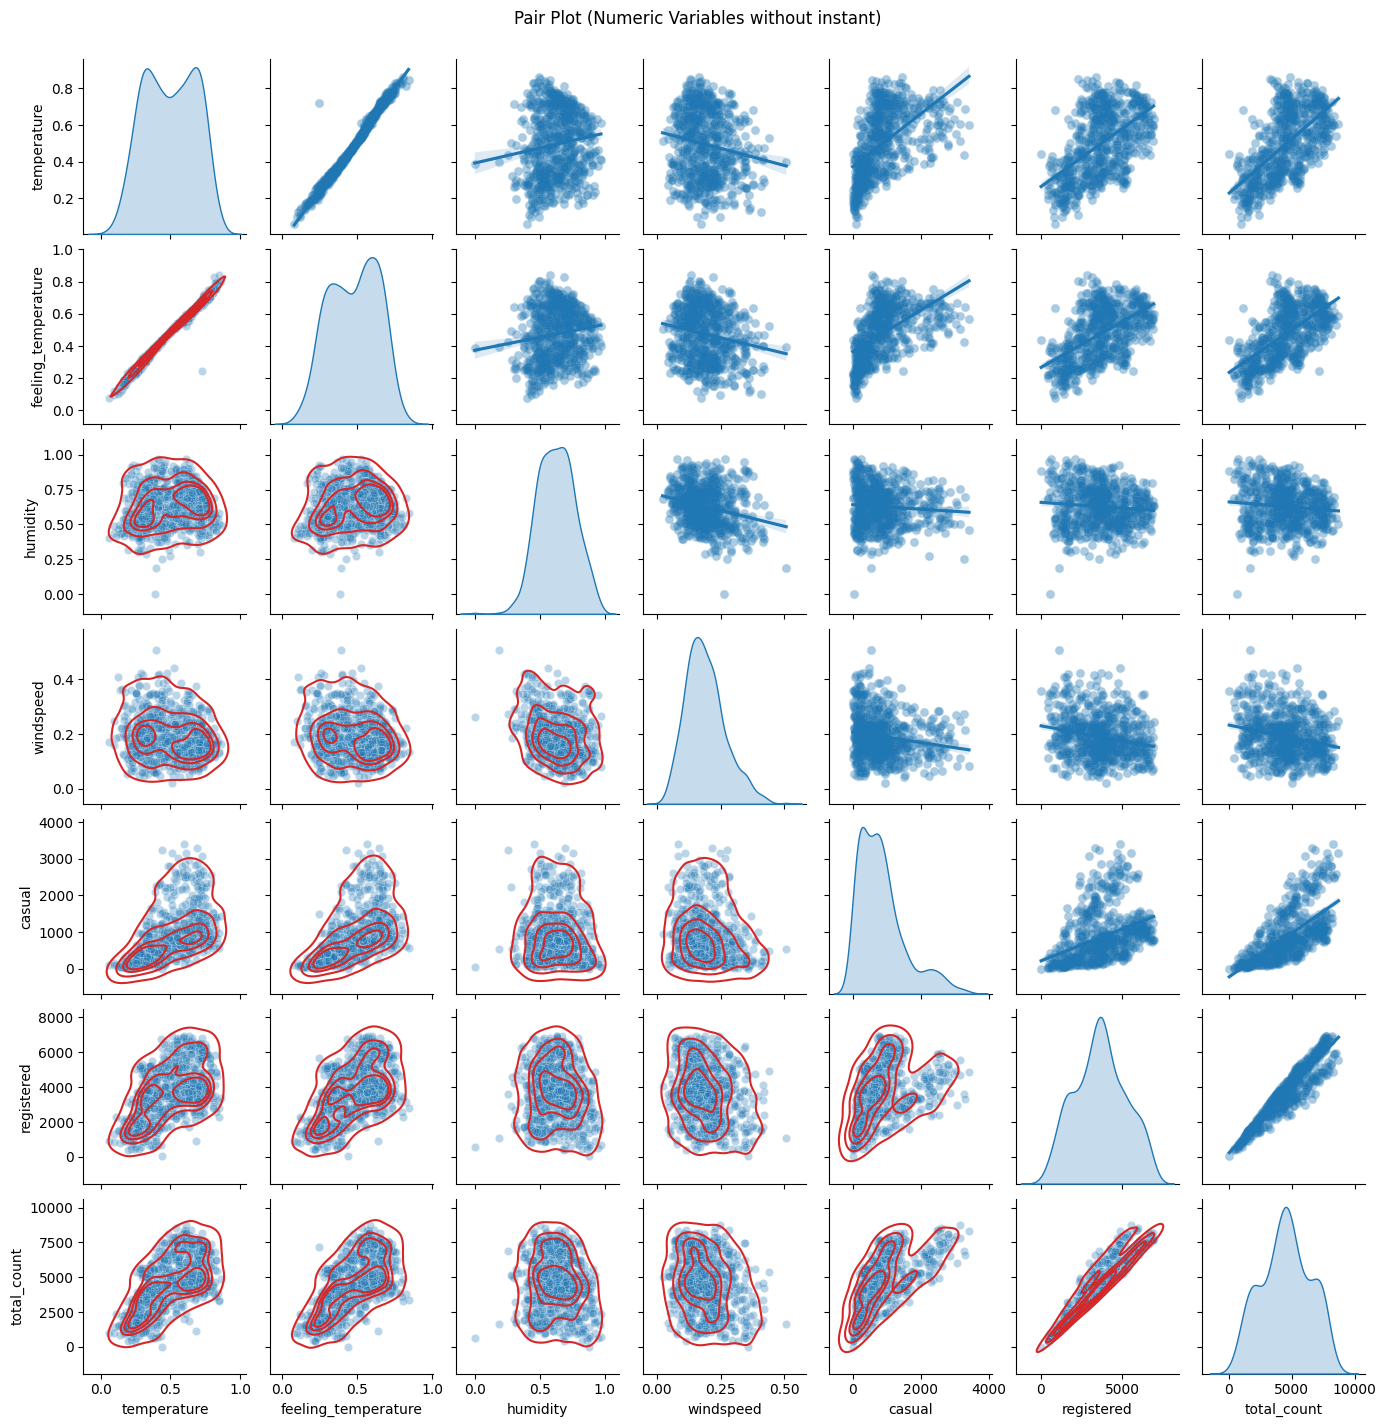

In [ ]:
# exclude 'instant' from numerical variables
num_vars = [col for col in numerical_variables if col != 'instant']
data = day_bike[num_vars]

# optional: custom palette
sns_c = sns.color_palette()

g = sns.pairplot(
    data=data,
    diag_kind='kde',
    height=2,
    corner=False,
    plot_kws={'alpha': 0.3}
)

# untere Dreieckszellen: KDE-Contours
g.map_lower(
    sns.kdeplot,
    levels=5,
    color=sns_c[3]
)

# obere Dreieckszellen: Regressionslinien
g.map_upper(
    sns.regplot,
    color=sns_c[0],
    scatter_kws={'alpha': 0.1}
)

# Titel anpassen
g.fig.suptitle('Pair Plot (Numeric Variables)', y=1.02)

plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Liste der zu prüfenden numerischen Variablen
features = ['temperature', 'humidity', 'windspeed', 'casual', 'feeling_temperature', 'total_count']

# DataFrame für VIF-Berechnung (ohne NaNs)
X = day_bike[features].dropna()

# Konstanten‐Spalte hinzufügen (für VIF-Berechnung)
X['constant'] = 1

# VIF-Werte berechnen
vif_data = pd.DataFrame({
    'feature': features,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(len(features))
    ]
})

print(vif_data)

               feature        VIF
0          temperature  63.104923
1             humidity   1.185795
2            windspeed   1.189058
3               casual   1.922367
4  feeling_temperature  63.984072
5          total_count   2.393392


### Regressionsergebnis: total_count ~ temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):           2.81e-81
Time:                        17:48:17   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1214.6421    161.164      7.537      

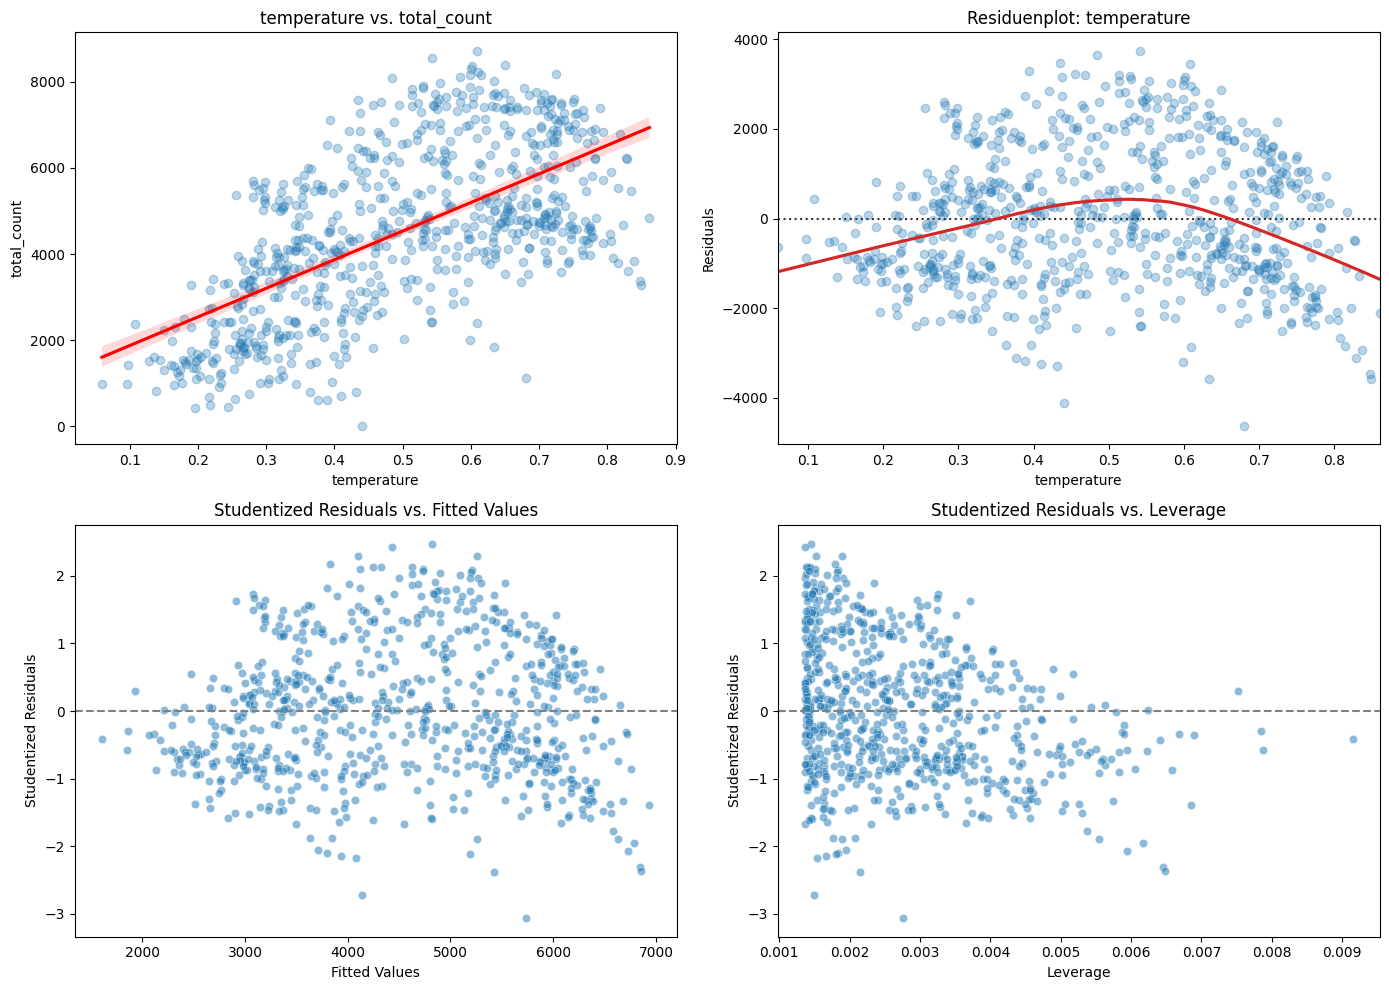

### Regressionsergebnis: total_count ~ humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):            0.00645
Time:                        17:48:20   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5363.9865    322.679     16.623      0.0

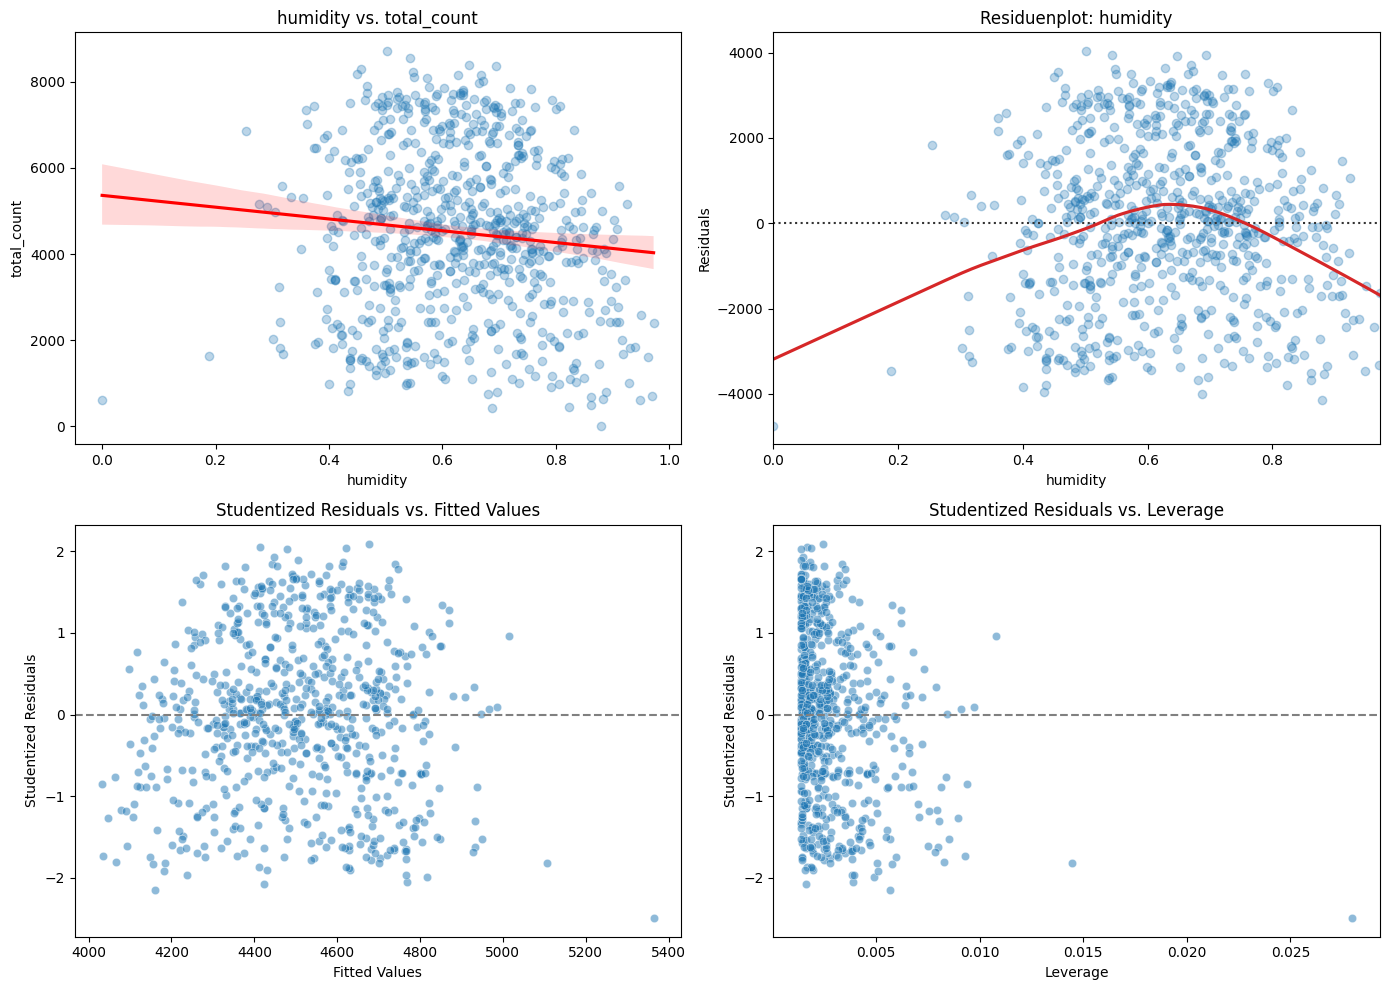

### Regressionsergebnis: total_count ~ windspeed

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):           1.36e-10
Time:                        17:48:24   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5621.1529    185.062     30.374      0.0

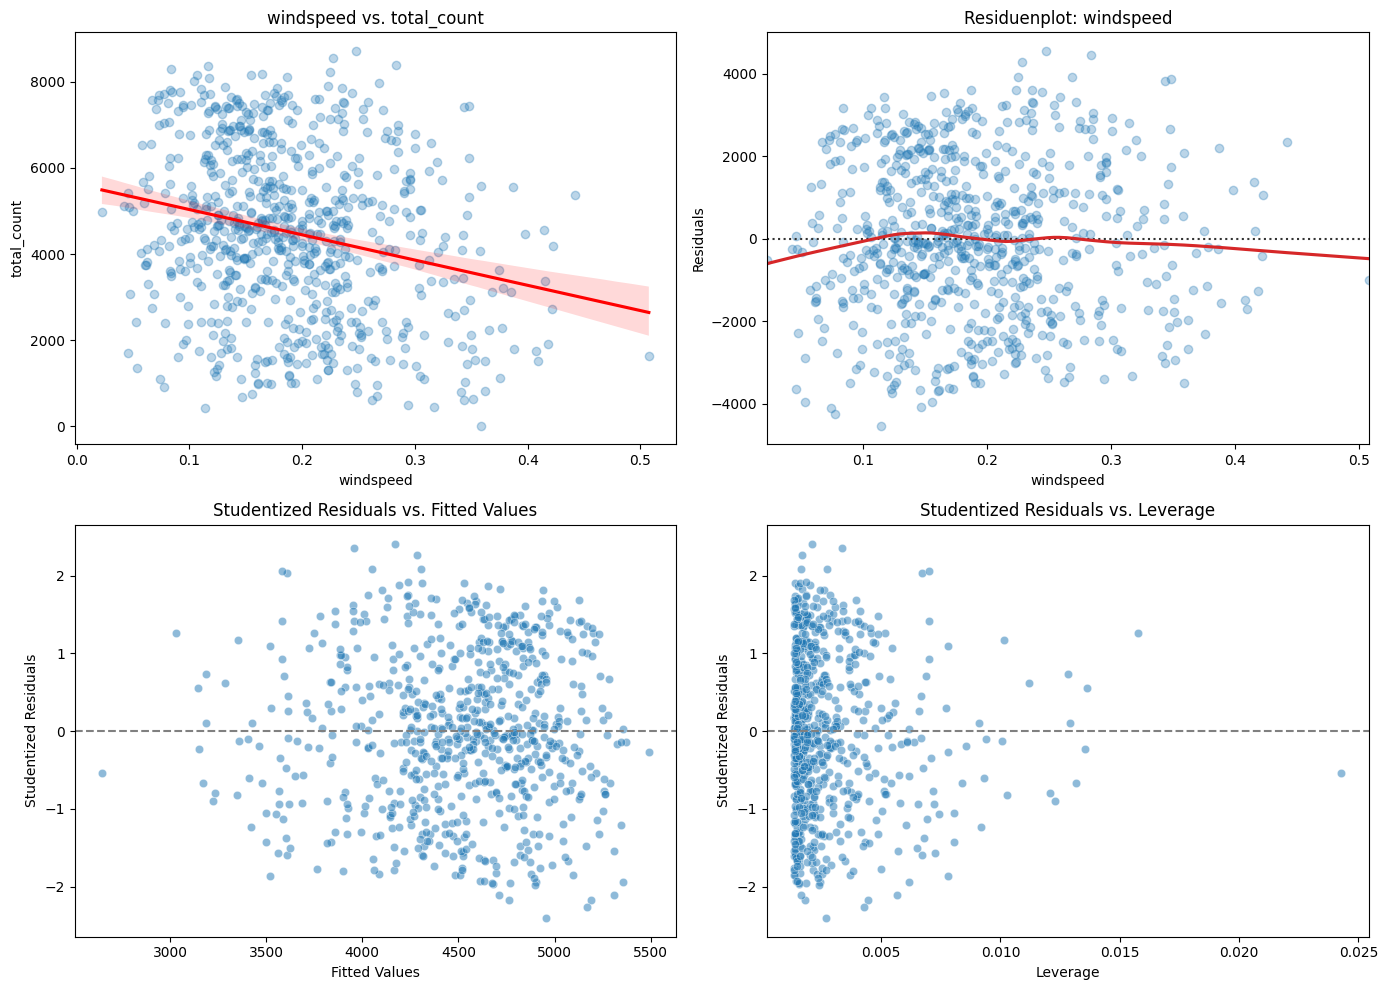

### Regressionsergebnis: total_count ~ casual

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     602.9
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):           1.72e-97
Time:                        17:48:26   Log-Likelihood:                -6349.4
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     729   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2894.3185     84.340     34.317      0.0

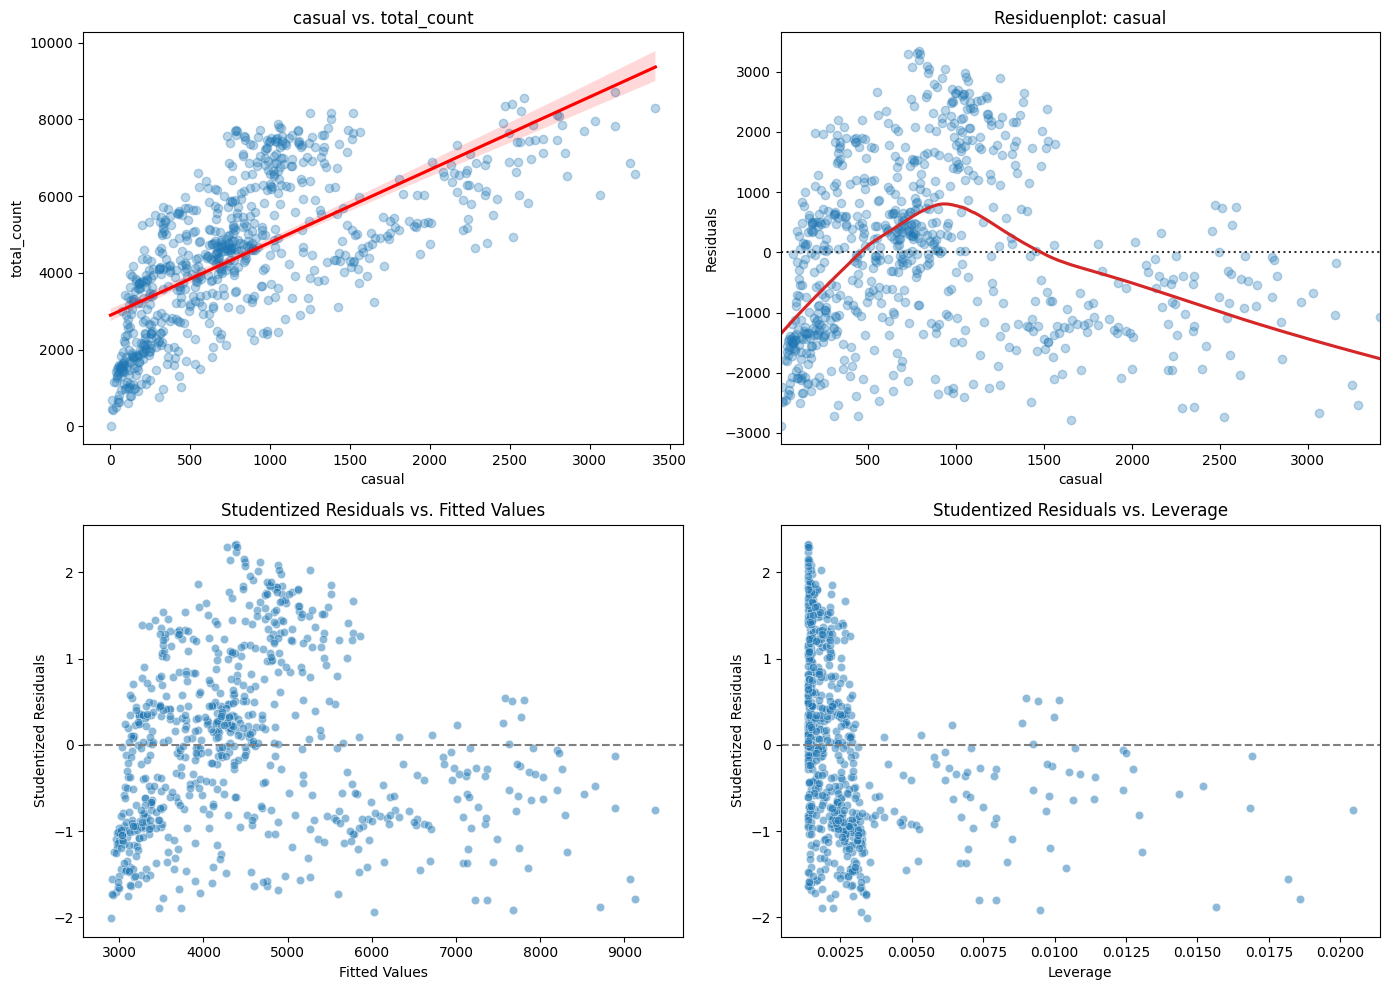

### Regressionsergebnis: total_count ~ registered

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     6149.
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:48:28   Log-Likelihood:                -5749.4
No. Observations:                 731   AIC:                         1.150e+04
Df Residuals:                     729   BIC:                         1.151e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        212.1777     59.508      3.566      0.0

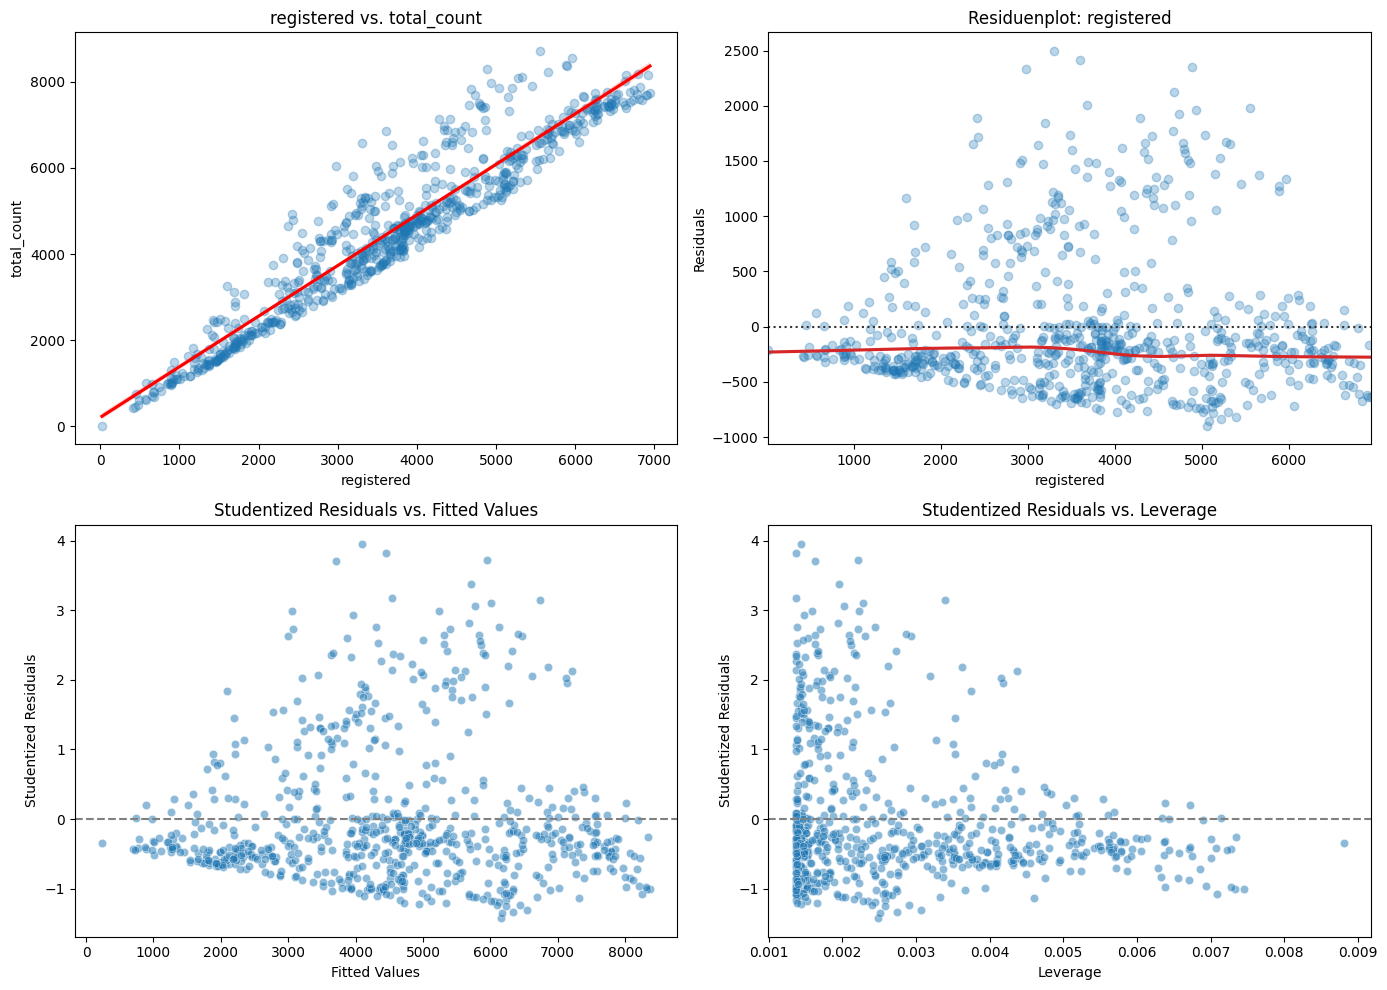

In [25]:
features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']
target = 'total_count'

# dict to hold fitted models
models = {}
for feat in features:
    # 1. Regression mit statsmodels
    X = sm.add_constant(day_bike[feat])
    model = sm.OLS(day_bike[target], X).fit()
    
    # store model for later access
    models[feat] = model
    
    # Diagnostische Werte berechnen
    influence = model.get_influence()
    stud_residuals = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag
    
    # 2. Ausgabe der Modellzusammenfassung
    display(Markdown(f"### Regressionsergebnis: {target} ~ {feat}"))
    print(model.summary())
    
    # 3. Ein 2x2-Raster für die Plots erstellen
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Obere Reihe: Bestehende Plots ---
    sns.regplot(x=feat, y=target, data=day_bike,
                ax=axes[0, 0], scatter_kws={'alpha': 0.3},
                line_kws={'color': 'red'})
    axes[0, 0].set_title(f'{feat} vs. {target}')
    
    sns.residplot(x=day_bike[feat], y=model.resid,
                  ax=axes[0, 1], lowess=True,
                  scatter_kws={'alpha': 0.3},
                  line_kws={'color': 'C3'})
    axes[0, 1].set_title(f'Residuenplot: {feat}')
    axes[0, 1].set_ylabel("Residuals")

    # --- Untere Reihe: Neue diagnostische Plots ---
    # Studentized Residuals vs. Fitted Values
    sns.scatterplot(x=model.fittedvalues, y=stud_residuals, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].axhline(0, ls='--', color='gray')
    axes[1, 0].set_title('Studentized Residuals vs. Fitted Values')
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('Studentized Residuals')

    # Studentized Residuals vs. Leverage
    sns.scatterplot(x=leverage, y=stud_residuals, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].axhline(0, ls='--', color='gray')
    axes[1, 1].set_title('Studentized Residuals vs. Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Studentized Residuals')
    
    plt.tight_layout()
    plt.show()

## Quadratisches Modell: total_count ~ humidity + humidity²

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                Sat, 21 Jun 2025   Prob (F-statistic):           1.37e-13
Time:                        15:30:54   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1245.5145    954.185     -1.305      0.1

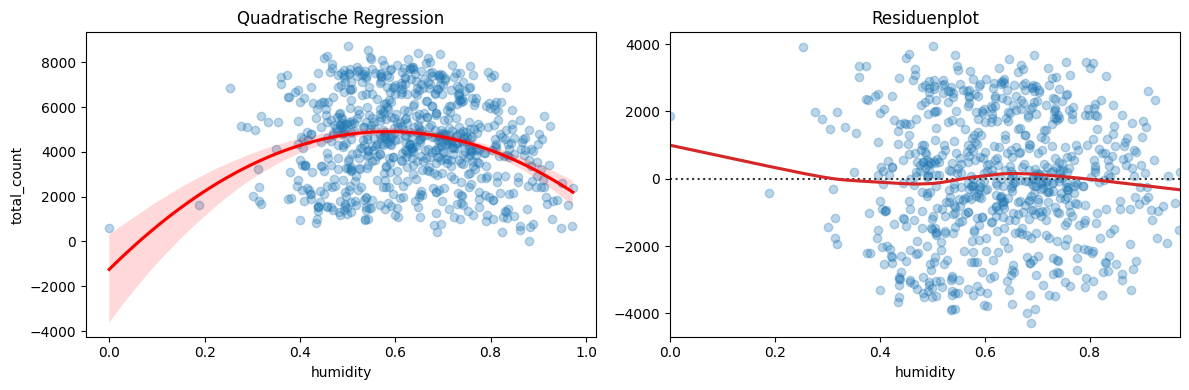

In [15]:
# Neue Zelle: Quadratisches Modell für humidity

import statsmodels.api as sm
from IPython.display import display, Markdown

# quadratischen Term einführen
day_bike['humidity2'] = day_bike['humidity']**2

X = sm.add_constant(day_bike[['humidity', 'humidity2']])
model_poly = sm.OLS(day_bike['total_count'], X).fit()

display(Markdown("## Quadratisches Modell: total_count ~ humidity + humidity²"))
print(model_poly.summary())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='humidity', y='total_count', data=day_bike, order=2,
            ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Quadratische Regression')
sns.residplot(x='humidity', y=model_poly.resid, data=day_bike,
              ax=axes[1], lowess=True, scatter_kws={'alpha':0.3},
              line_kws={'color':'C3'})
axes[1].set_title('Residuenplot')
plt.tight_layout()
plt.show()

## Boxplots of Numerical Variables (Outlier Detection)

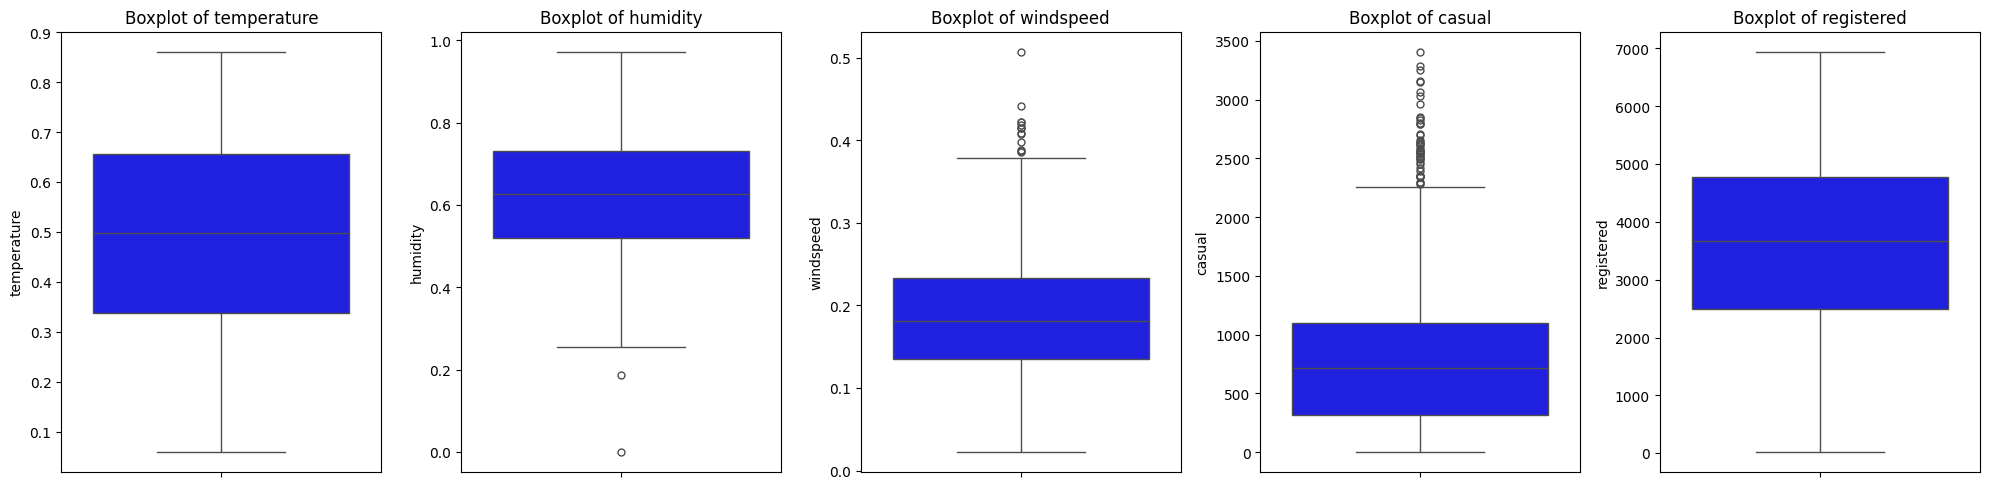

In [16]:
#Boxplots for Numerical Features to Identify Outliers



# List of numerical features to inspect
num_features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']

display(Markdown("## Boxplots of Numerical Variables (Outlier Detection)"))

# Create one row of subplots, one boxplot per feature
fig, axes = plt.subplots(nrows=1,
                         ncols=len(num_features),
                         figsize=(20, 5),
                         sharey=False)

# Loop over features and axes to draw boxplots
for ax, feature in zip(axes, num_features):
    sns.boxplot(y=day_bike[feature],
                ax=ax,
                color='blue',
                fliersize=5,
                linewidth=1)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1695395544.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0][1].set_xticklabels(['spring', 'summer', 'fall', 'winter'])
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1695395544.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1][0].set_xticklabels(['2011', '2012'])
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1695395544.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1][1].set_xticklabels(['Clear', 'Mist', 'Snow'])
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1695395544.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2][1].set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])


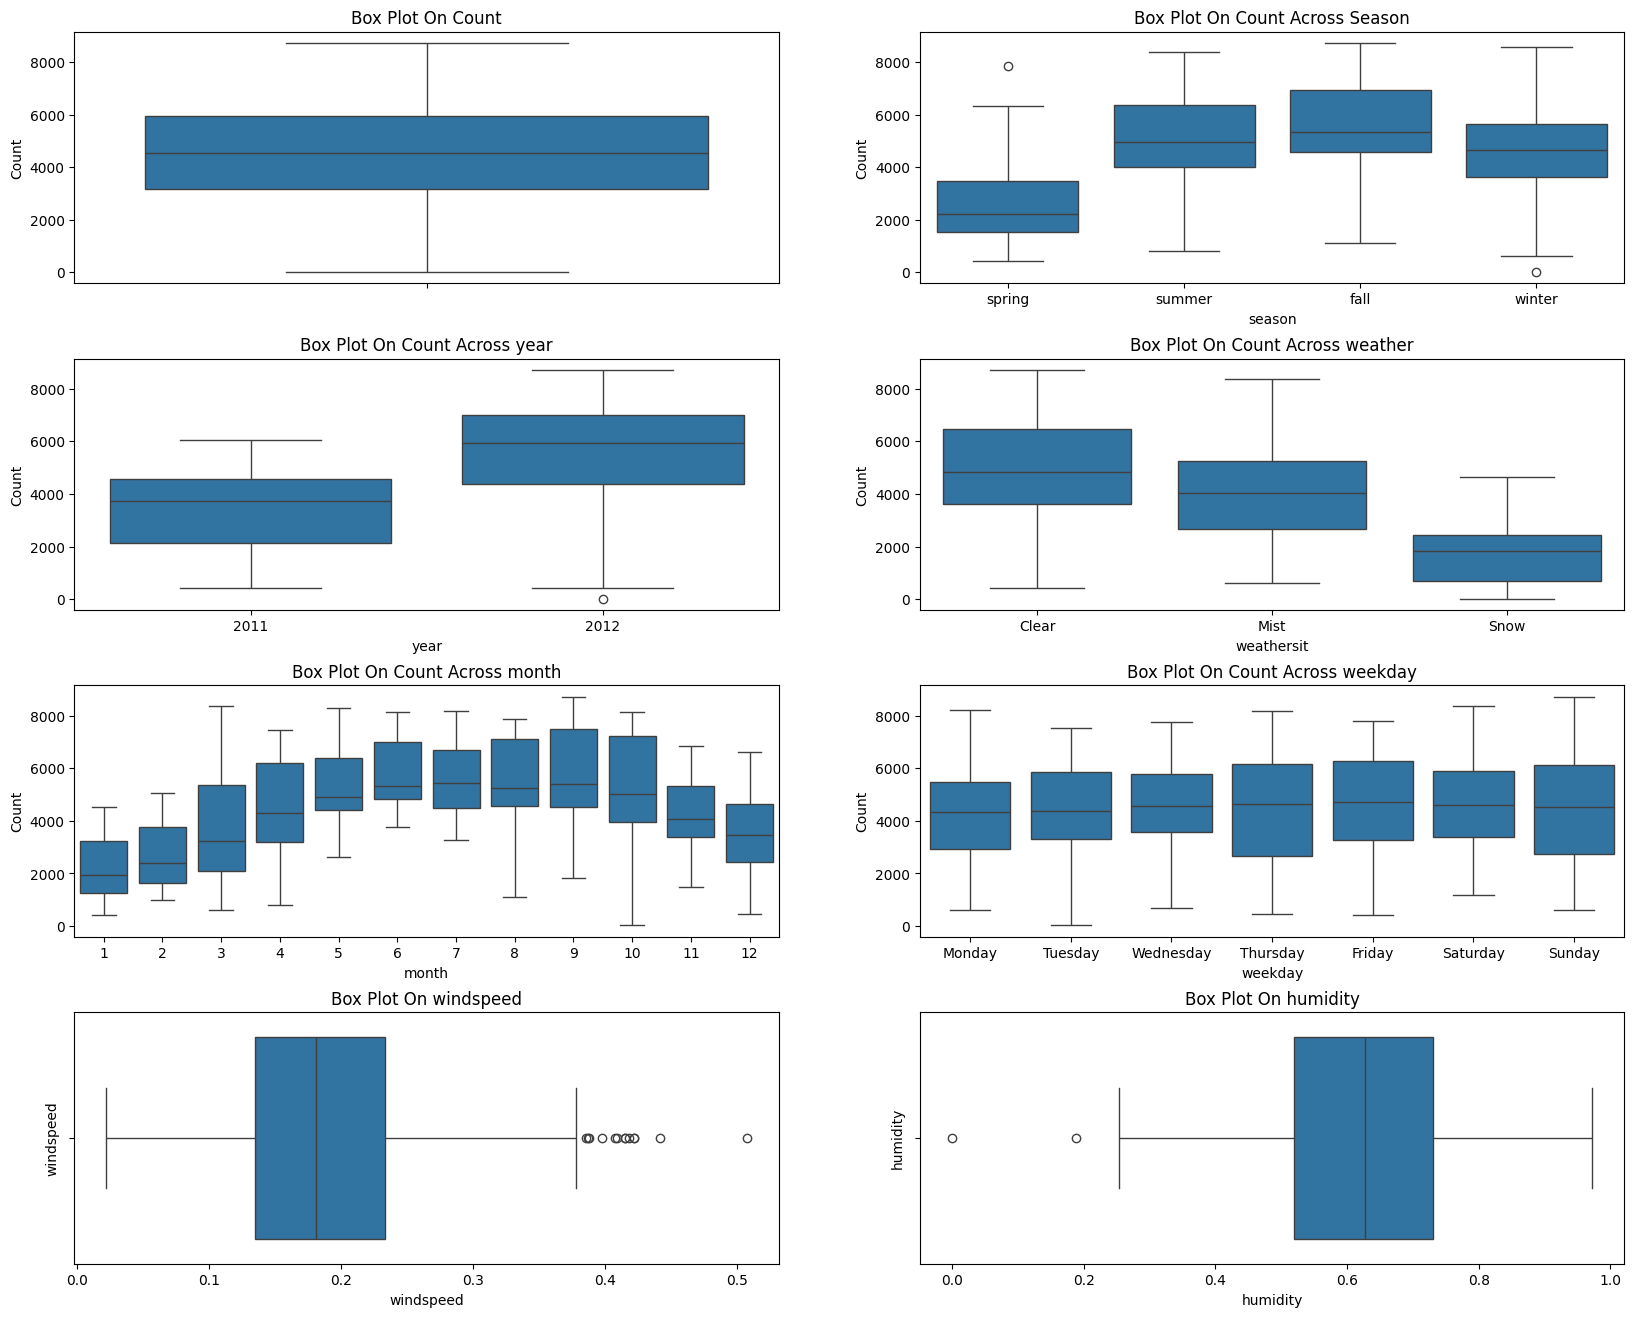

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=4, ncols=2)
fig.set_size_inches(20, 16)
plt.subplots_adjust(hspace=0.3)

# Boxplots für kategorische und kontinuierliche Features
sns.boxplot(data=day_bike, y="total_count", ax=axes[0][0])
sns.boxplot(data=day_bike, y="total_count", x="season", ax=axes[0][1])
sns.boxplot(data=day_bike, y="total_count", x="year", ax=axes[1][0])
sns.boxplot(data=day_bike, y="total_count", x="weathersit", ax=axes[1][1])
sns.boxplot(data=day_bike, y="total_count", x="month", ax=axes[2][0])
sns.boxplot(data=day_bike, y="total_count", x="weekday", ax=axes[2][1])
sns.boxplot(data=day_bike, x="windspeed", ax=axes[3][0])
sns.boxplot(data=day_bike, x="humidity", ax=axes[3][1])

axes[0][0].set(ylabel='Count', title="Box Plot On Count")
axes[0][1].set(ylabel='Count', title="Box Plot On Count Across Season")
axes[0][1].set_xticklabels(['spring', 'summer', 'fall', 'winter'])

axes[1][0].set(ylabel='Count', title="Box Plot On Count Across year")
axes[1][0].set_xticklabels(['2011', '2012'])

axes[1][1].set(ylabel='Count', title="Box Plot On Count Across weather")
axes[1][1].set_xticklabels(['Clear', 'Mist', 'Snow'])

axes[2][0].set(ylabel='Count', title="Box Plot On Count Across month")
axes[2][1].set(ylabel='Count', title="Box Plot On Count Across weekday")
axes[2][1].set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

axes[3][0].set(ylabel='windspeed', title="Box Plot On windspeed")
axes[3][1].set(ylabel='humidity', title="Box Plot On humidity")

plt.show()

## Boxplots of Categorical Variables vs. total_count

C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1250286354.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1250286354.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(['2011', '2012']) # For 'year'
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1250286354.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2].set_xticklabels(['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1250286354.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[4].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
C:\Users\chris\AppData\Local\Temp\ipykernel_4396\1250286354.py:32: UserWarning: FixedFormatter should only be u

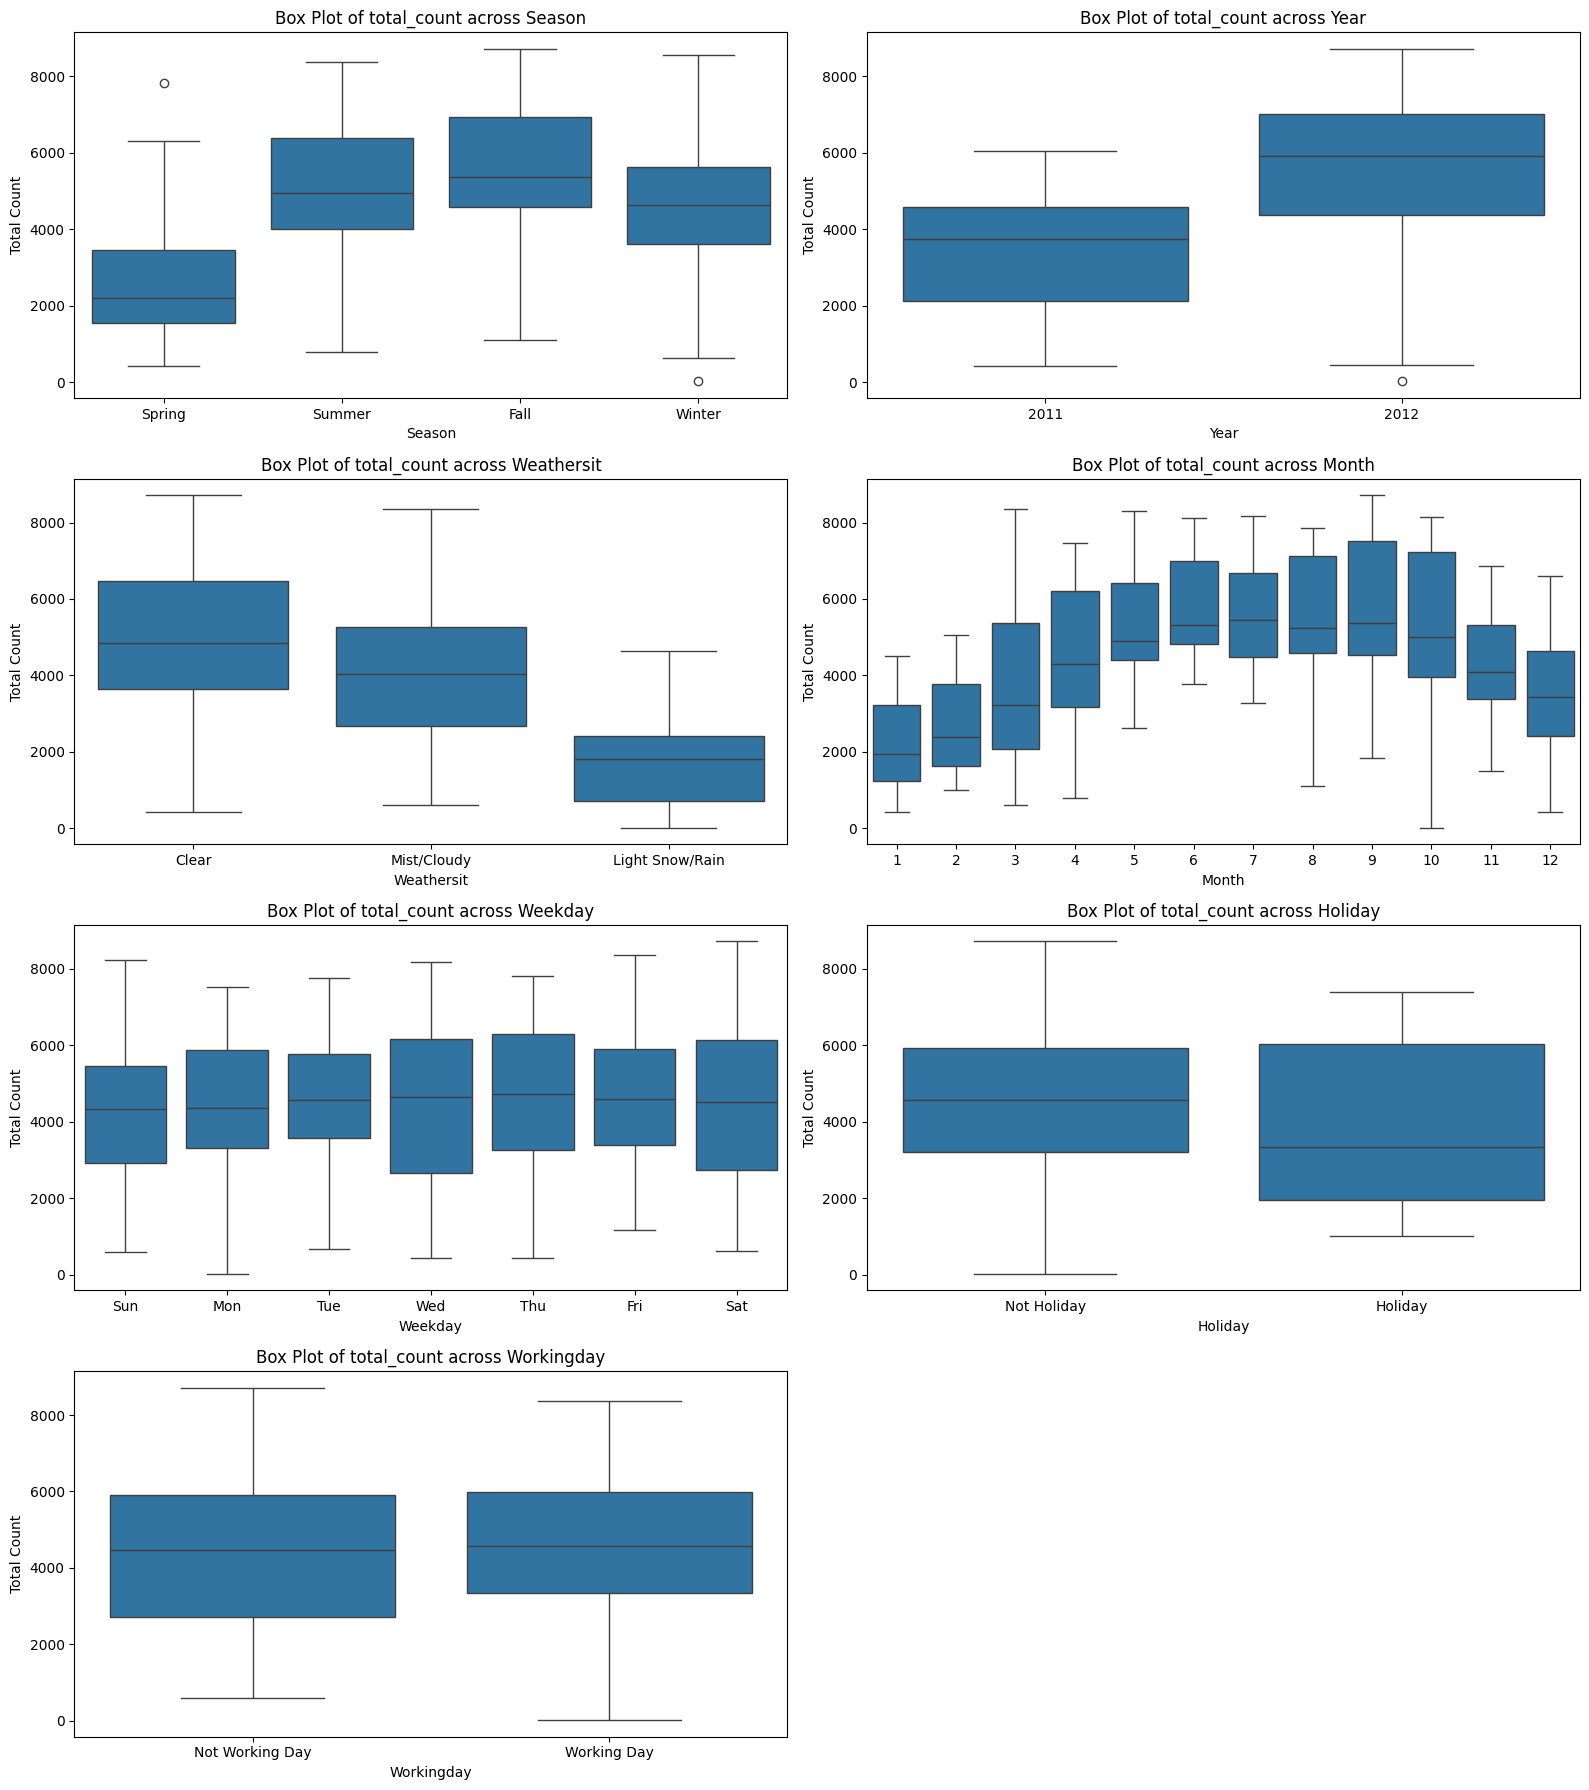

In [19]:
#Boxplots for Categorical Features vs. Total Count


# Define the categorical features to be plotted against the target variable
cat_features_for_plot = ['season', 'year', 'weathersit', 'month', 'weekday', 'holiday', 'workingday']
target = 'total_count'

# Create a figure and a set of subplots. A 4x2 grid.
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
# Flatten the axes array for easy iteration, which simplifies assigning plots to subplots
axes = axes.flatten()

display(Markdown(f"## Boxplots of Categorical Variables vs. {target}"))

# --- Plotting Loop ---
# Iterate through the list of categorical features and create a boxplot for each.
# 'enumerate' provides an index 'i' and the 'feature' name.
for i, feature in enumerate(cat_features_for_plot):
    ax = axes[i]
    # Create the boxplot using seaborn, assigning it to the current subplot axis
    sns.boxplot(data=day_bike, x=feature, y=target, ax=ax)
    # Set a descriptive title for each subplot
    ax.set_title(f'Box Plot of {target} across {feature.capitalize()}')
    ax.set_ylabel('Total Count')
    ax.set_xlabel(feature.capitalize())

# --- Customizing Labels for better readability ---
axes[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
axes[1].set_xticklabels(['2011', '2012']) # For 'year'
axes[2].set_xticklabels(['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
axes[4].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
axes[5].set_xticklabels(['Not Holiday', 'Holiday']) # For 'holiday'
axes[6].set_xticklabels(['Not Working Day', 'Working Day']) # For 'workingday'

# Hide the last subplot if it's unused (since we have 7 plots in a 4x2 grid)
axes[7].set_visible(False)

# Adjust the layout automatically to prevent titles and labels from overlapping
plt.tight_layout()
# Display the generated

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

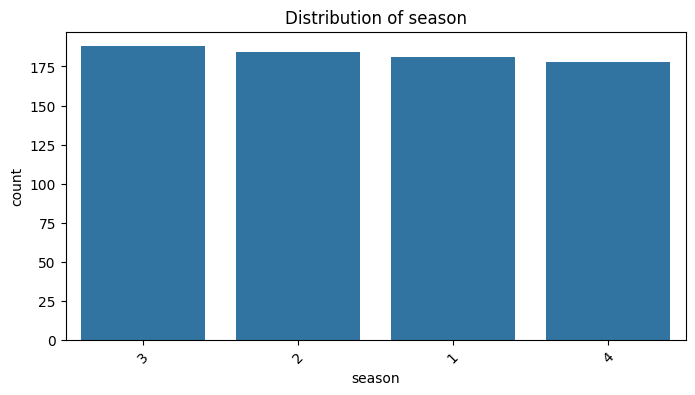

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

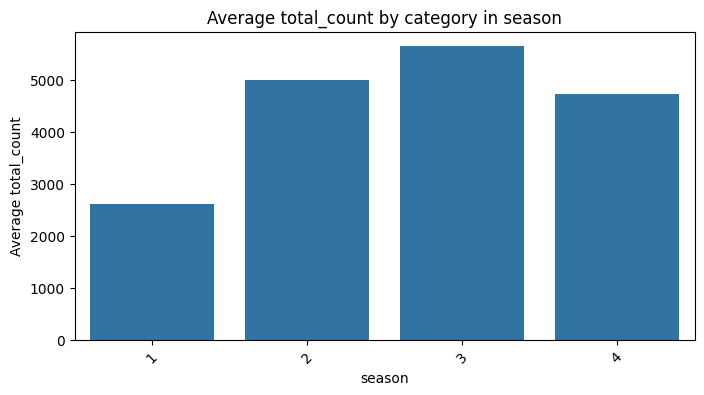

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

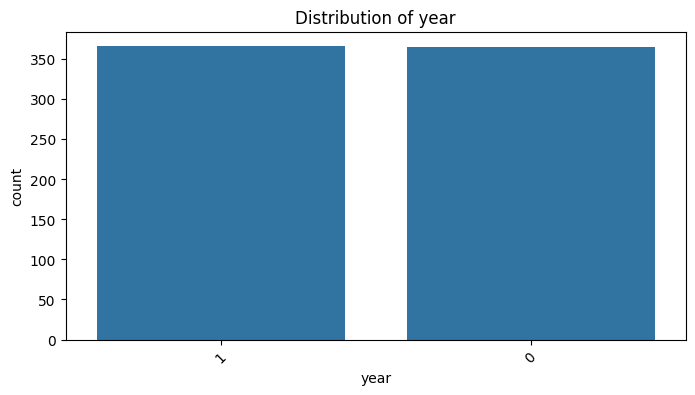

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

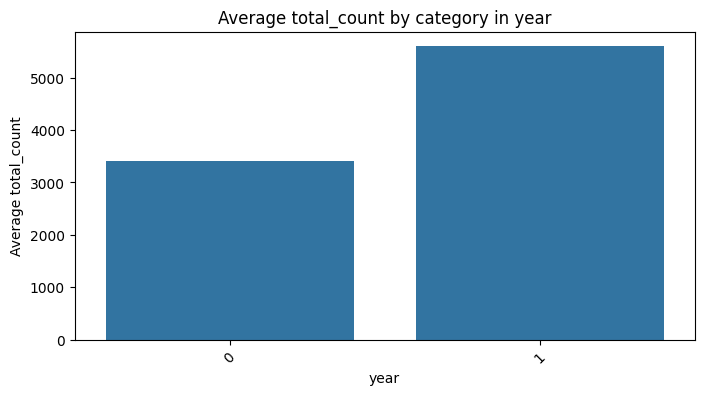

### Feature: month

month
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

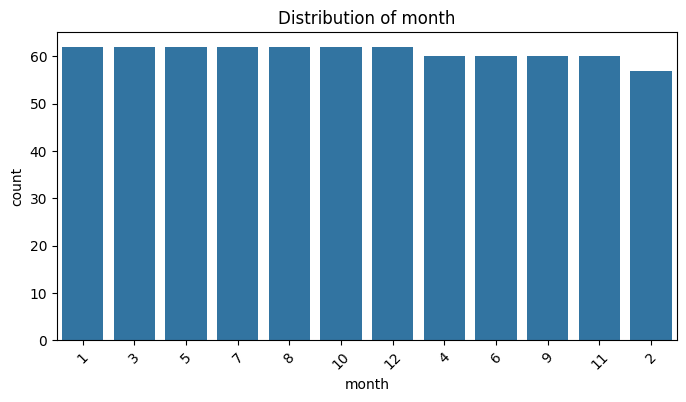

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

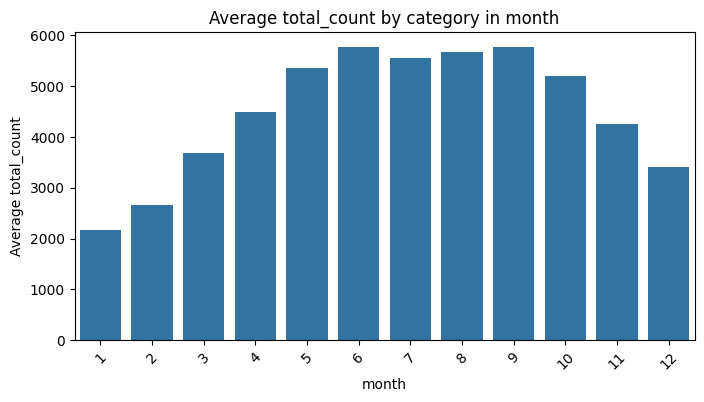

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

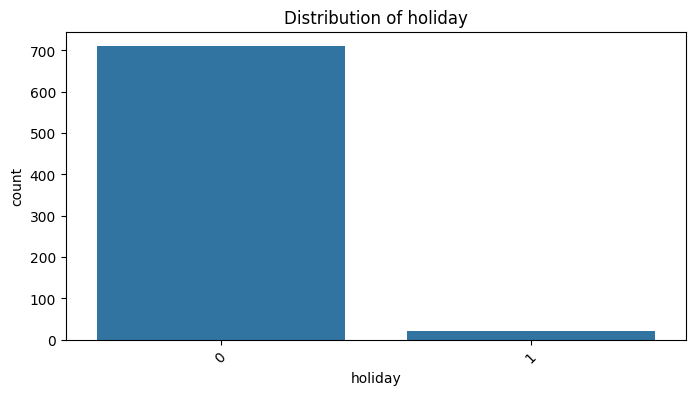

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

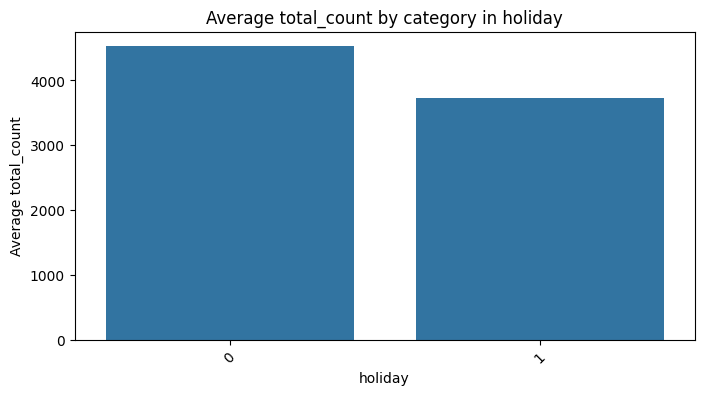

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

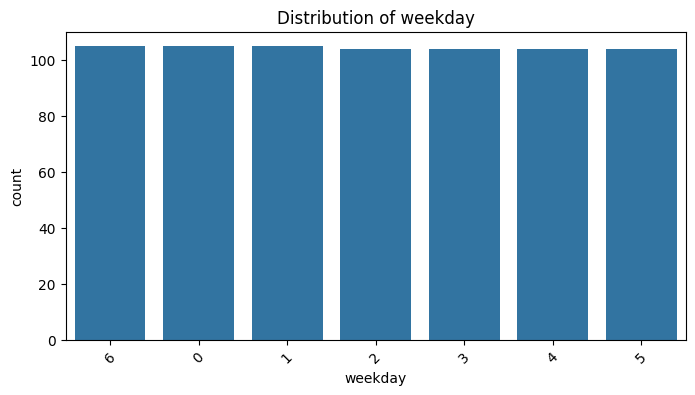

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

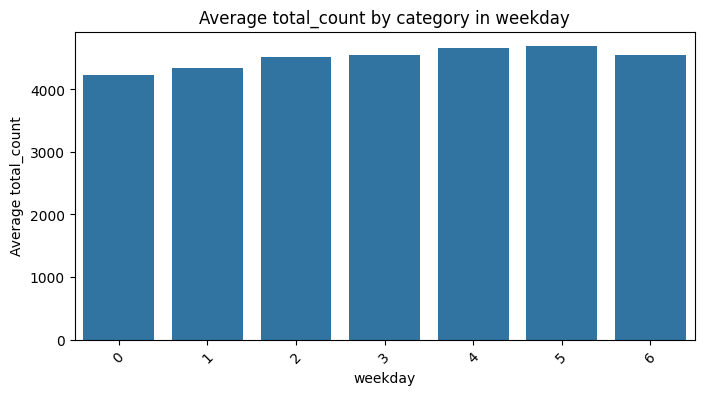

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

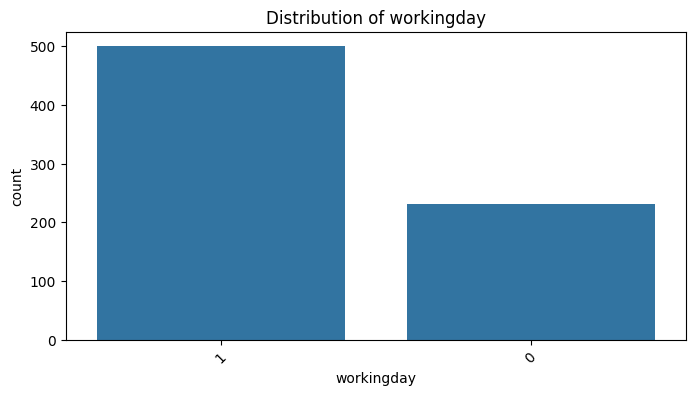

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

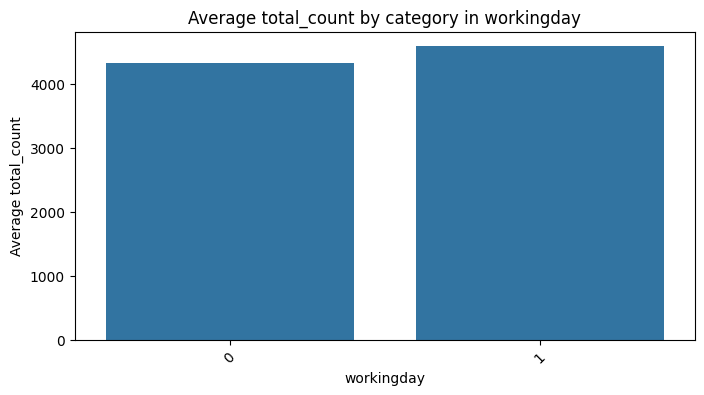

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

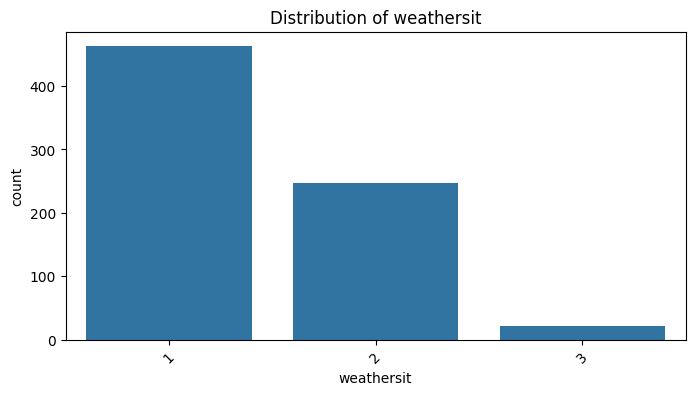

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

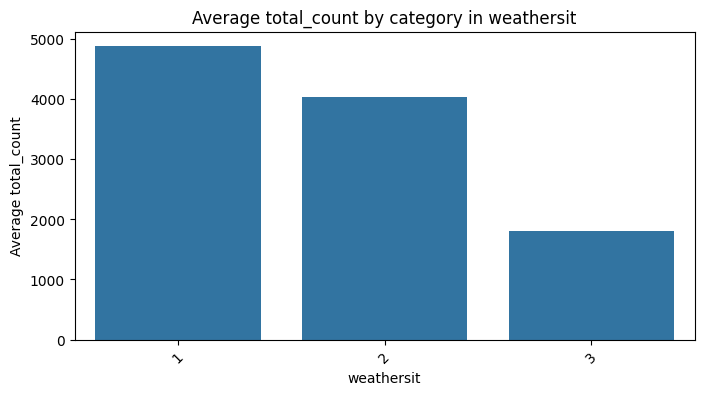

In [20]:
# New Cell: Analysis of Categorical Variables
from IPython.display import display, Markdown

def analyze_categorical_features(df, cat_features, target=None):
    """
    Analyzes categorical variables:
    - Displays frequency distributions
    - Plots countplots for each feature
    - (Optional) Aggregates by feature and calculates the mean of the target variable
    """
    display(Markdown("## Analysis of Categorical Variables"))
    
    for feature in cat_features:
        display(Markdown(f"### Feature: {feature}"))
        
        # Display the frequency distribution
        counts = df[feature].value_counts()
        display(counts)
        
        # Create a countplot
        plt.figure(figsize=(8, 4))
        sns.countplot(x=feature, data=df, order=counts.index)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()
        
        # Optional analysis: aggregate target variable if provided
        if target is not None and target in df.columns:
            group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
            display(Markdown(f"**Average {target} by {feature}:**"))
            display(group_stats)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_stats.index, y=group_stats.values)
            plt.title(f'Average {target} by category in {feature}')
            plt.xticks(rotation=45)
            plt.ylabel(f'Average {target}')
            plt.show()

# Calling the function with your categorical variables
analyze_categorical_features(day_bike, categorical_variables, target="total_count")

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

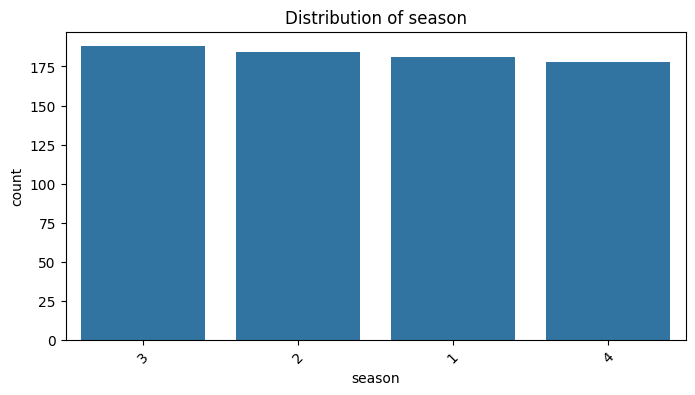

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

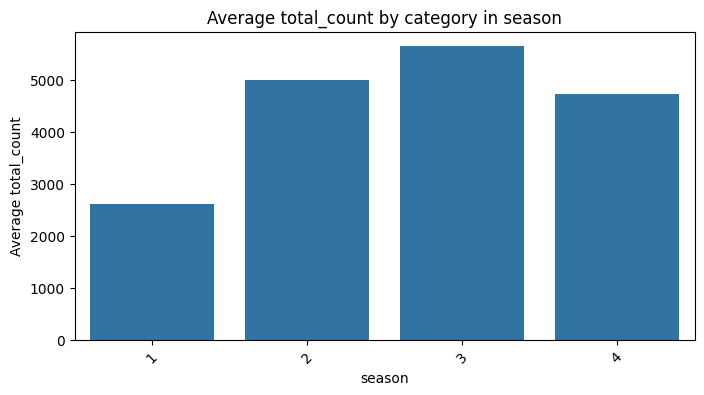

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

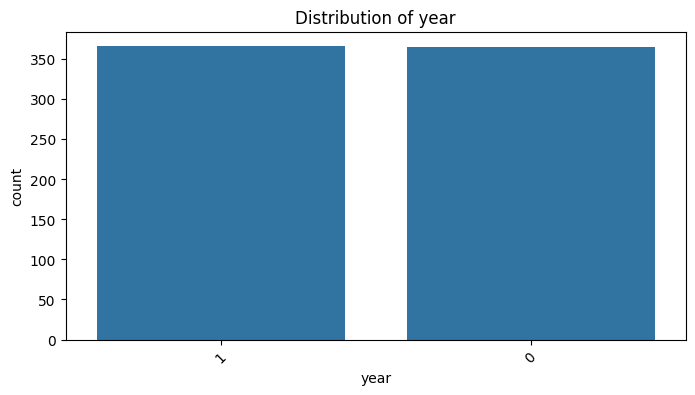

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

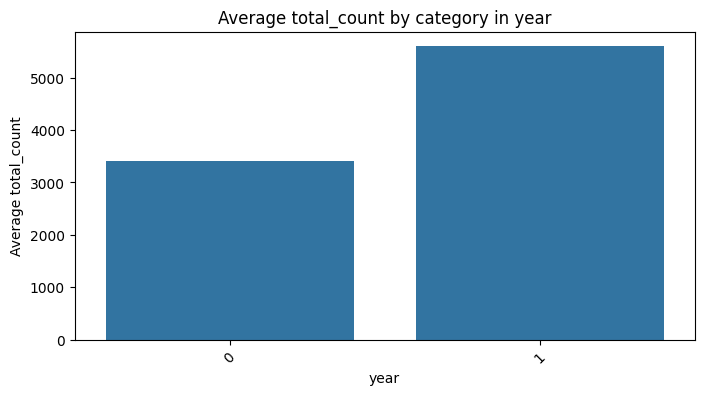

### Feature: month

month
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

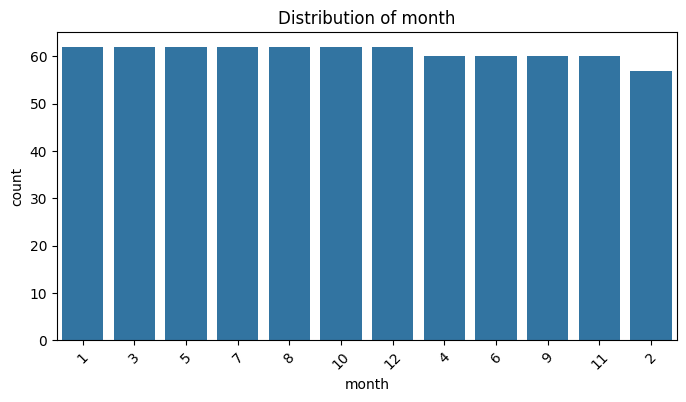

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

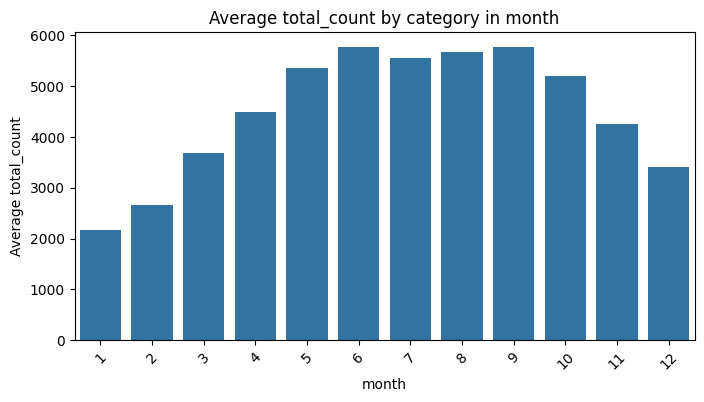

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

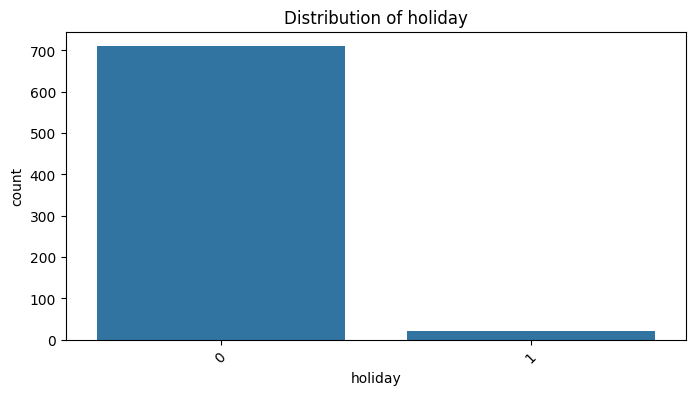

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

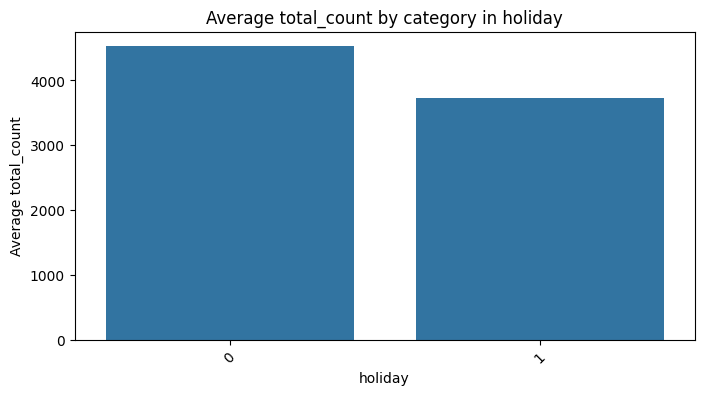

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

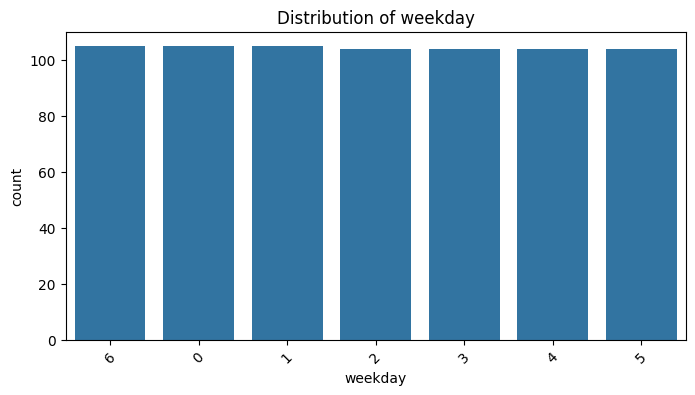

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

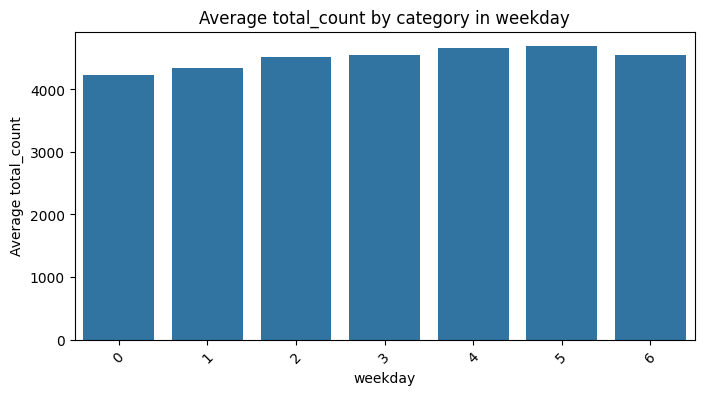

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

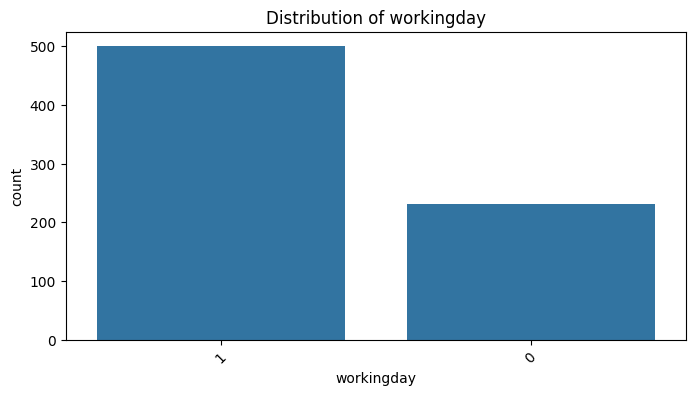

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

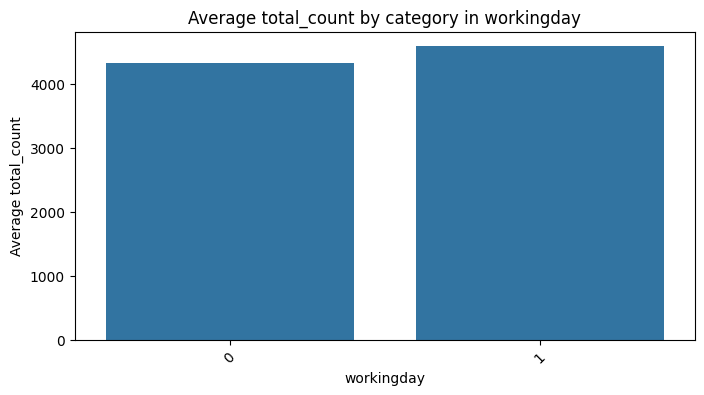

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

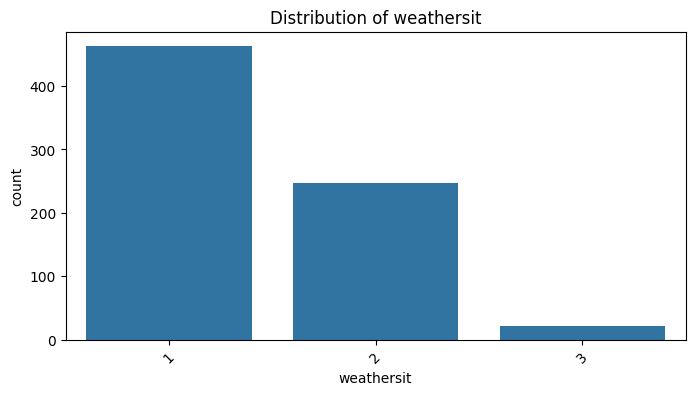

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

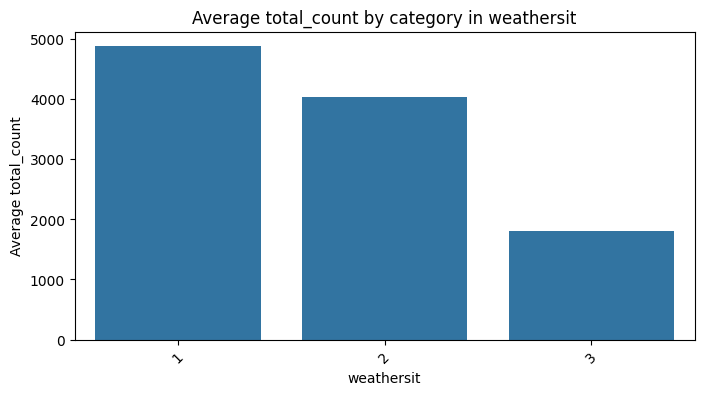

In [21]:
# New Cell: Analysis of Categorical Variables
from IPython.display import display, Markdown

def analyze_categorical_features(df, cat_features, target=None):
    """
    Analyzes categorical variables:
    - Displays frequency distributions
    - Plots countplots for each feature
    - (Optional) Aggregates by feature and calculates the mean of the target variable
    """
    display(Markdown("## Analysis of Categorical Variables"))
    
    for feature in cat_features:
        display(Markdown(f"### Feature: {feature}"))
        
        # Display the frequency distribution
        counts = df[feature].value_counts()
        display(counts)
        
        # Create a countplot
        plt.figure(figsize=(8, 4))
        sns.countplot(x=feature, data=df, order=counts.index)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()
        
        # Optional analysis: aggregate target variable if provided
        if target is not None and target in df.columns:
            group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
            display(Markdown(f"**Average {target} by {feature}:**"))
            display(group_stats)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_stats.index, y=group_stats.values)
            plt.title(f'Average {target} by category in {feature}')
            plt.xticks(rotation=45)
            plt.ylabel(f'Average {target}')
            plt.show()

# Calling the function with your categorical variables
analyze_categorical_features(day_bike, categorical_variables, target="total_count")

In [ ]:

def detect_outliers_and_leverage(df, feature_cols, target_col, outlier_factor=3.0):
    """
    Fits an OLS regression model on the specified features and target,
    computes influence measures and flags:
      - is_potential_outlier: |studentized residual| > outlier_factor
      - is_high_leverage: hat value > (p+1)/n
    """
    # Prepare design matrix
    X = df[feature_cols].copy()
    X = sm.add_constant(X)
    y = df[target_col]

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Influence measures
    infl = model.get_influence()
    hat_vals = infl.hat_matrix_diag
    stud_resid = infl.resid_studentized_internal

    # Thresholds
    n, p = X.shape[0], X.shape[1] - 1
    leverage_thresh = (p + 1) / n

    # Flags
    is_outlier = np.abs(stud_resid) > outlier_factor
    is_high_lev = hat_vals > leverage_thresh

    # Build results
    results = pd.DataFrame({
        'residuals': model.resid,
        'standardized_residuals': stud_resid,
        'leverage': hat_vals,
        'cooks_distance': infl.cooks_distance[0],
        'is_potential_outlier': is_outlier,
        'is_high_leverage': is_high_lev,
        'fitted_values': model.fittedvalues
    }, index=df.index)

    return results, model


In [ ]:
#Applying the Outlier/Leverage Detection Function


# 1. Define the feature sets and the target variable
numerical_features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']
# Note: 'month' and 'weekday' can be treated as categorical
categorical_features = ['season', 'year', 'month', 'weekday', 'weathersit', 'holiday', 'workingday']
target_col = 'total_count'

# 2. Create one-hot encoded features from the categorical variables
# Using drop_first=True to avoid perfect multicollinearity
day_bike_dummies = pd.get_dummies(day_bike[categorical_features], 
                                  columns=categorical_features, 
                                  drop_first=True, 
                                  dtype=float)

# 3. Combine the numerical features and the new dummy variables
X_full = pd.concat([day_bike[numerical_features], day_bike_dummies], axis=1)

# The function needs a single DataFrame with both features and target
df_for_model = pd.concat([X_full, day_bike[target_col]], axis=1)

# 4. Get the final list of all predictor columns
all_feature_cols = X_full.columns.tolist()

# 5. Call the detection function with the prepared data
# We can adjust the outlier_fraction, e.g., to 5% for the full model
influence_df, full_model = detect_outliers_and_leverage(
    df=df_for_model,
    feature_cols=all_feature_cols,
    target_col=target_col 
)

# 6. Display the summary of the fitted regression model
display(Markdown("## Full Regression Model Summary"))
print(full_model.summary())

# 7. Display the points that were flagged as either potential outliers or high-leverage
display(Markdown("## Identified Potential Outliers and/or High-Leverage Points"))
problematic_points = influence_df[
    (influence_df['is_potential_outlier']) | (influence_df['is_high_leverage'])
]
display(problematic_points)

print(f"\nTotal number of problematic points found: {len(problematic_points)}")

## Full Regression Model Summary

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.185e+30
Date:                 Sa, 21 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:47:38   Log-Likelihood:                 18282.
No. Observations:                 731   AIC:                        -3.650e+04
Df Residuals:                     701   BIC:                        -3.637e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -7.603e-13   1.08e-12     -0.706   

## Identified Potential Outliers and/or High-Leverage Points

,residuals,standardized_residuals,leverage,cooks_distance,is_potential_outlier,is_high_leverage,fitted_values
16,-1.477929e-12,-0.452257,0.074716,0.000533,False,True,1000.0
25,-2.955858e-12,-0.907792,0.081386,0.002355,False,True,506.0
31,-2.501110e-12,-0.752808,0.043608,0.000834,False,True,1360.0
35,-3.751666e-12,-1.129387,0.043904,0.001889,False,True,1005.0
39,-3.410605e-12,-1.026053,0.042668,0.001514,False,True,1605.0
...,...,...,...,...,...,...,...
726,4.547474e-13,0.138369,0.064162,0.000042,False,True,2114.0
727,9.094947e-13,0.275623,0.056574,0.000147,False,True,3095.0
728,-6.821210e-13,-0.207187,0.060850,0.000090,False,True,1341.0
729,1.591616e-12,0.482742,0.058144,0.000464,False,True,1796.0



Total number of problematic points found: 184


# 3. Modeling  

# 4. Model Evaluation  

# 5 Conclusion and Future Outlook